## Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

## Load the dataset

In [29]:
df = pd.read_csv("/Users/ethanc/RnA/data/test_sample_cleaned_v2.csv")
df.head(5)

,eventid,event_date,number_of_shows,headliner,support,venue,city,state,country,market,company_type,promoter,genre,avg_tickets_sold,avg_gross_usd,avg_event_capacity,avg_capacity_sold,ticket_price_min,ticket_price_max,ticket_price_avg,gt_avg_13w,gt_max_13w,gt_std_13w,gt_momentum_13w,gt_date_range,wiki_avg_views_30d,historical_concerts,day_of_week,month,year,lockdown,last_album_date,days_since_last_album,album_release_last_12m,census_market_name,market_population,past_year_avg_tickets,market_clean,acs_market,population,median_income,is_missing_support,is_missing_genre,is_missing_album_dates,year_offset,headliner_cleaned_aventura,headliner_cleaned_christian_nodal,headliner_cleaned_david_foster,headliner_cleaned_lord_huron,headliner_cleaned_randall_king,headliner_cleaned_other,support_cleaned_alex_fernández,support_cleaned_brandi_carlile_grouplove_kid_cut_up,support_cleaned_emo_philips,support_cleaned_erin_rae,support_cleaned_katharine_mcphee,support_cleaned_other,venue_cleaned_9_30_club,venue_cleaned_city_winery_atlanta,venue_cleaned_city_winery_nyc,venue_cleaned_city_winery_nashville,venue_cleaned_thalia_hall,venue_cleaned_other,city_cleaned_boston,city_cleaned_chicago,city_cleaned_new_york,city_cleaned_portland,city_cleaned_washington,city_cleaned_other,state_cleaned_california,state_cleaned_florida,state_cleaned_massachusetts,state_cleaned_new_york,state_cleaned_texas,state_cleaned_other,market_cleaned_boston_manchester,market_cleaned_chicago,market_cleaned_los_angeles,market_cleaned_new_york,market_cleaned_washington_dc_hagerstown,market_cleaned_other,company_type_cleaned_amphitheatre,company_type_cleaned_arena,company_type_cleaned_auditorium_theatre,company_type_cleaned_club,company_type_cleaned_stadium,company_type_cleaned_other,promoter_cleaned_in_house_productions_city_winery,promoter_cleaned_in_house_promotion,promoter_cleaned_aeg_presents,promoter_cleaned_cárdenas_marketing_network_cmn,promoter_cleaned_live_nation,promoter_cleaned_other,genre_cleaned_country,genre_cleaned_dance_electronic,genre_cleaned_latin,genre_cleaned_pop_rock,genre_cleaned_rap_hiphop,genre_cleaned_other,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,ID0badbd5e13,2024-09-24,-0.19251,NCT Dream,NaN,Capital One Arena,Washington,District of Columbia,United States,"Washington, D.C. (Hagerstown)",Arena,Live Nation,Asian Pop,0.387887,0.456655,0.322590,0.919471,1.032057,0.493716,1.907539,-0.160256,-0.172999,-0.190879,0.012861,2019-09-03 2024-10-01,-0.126504,-0.775878,1,9,2024,0,2023-07-17,-0.466974,0,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.285038,0.675613,"Washington, D.C. (Hagerstown)","Washington-Arlington-Alexandria, DC-VA-MD-WV M...",6263796.0,2.421494,1,0,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,-1.0,-1.836970e-16,0.781831,0.623490
1,ID42a22a7467,2024-09-21,-0.19251,NCT Dream,NaN,UBS Arena,Belmont Park,New York,United States,New York,Arena,Live Nation,Asian Pop,0.707544,0.734636,0.637229,0.919471,0.765605,0.461027,1.845549,-0.160256,-0.172999,-0.190879,0.012862,2019-09-03 2024-10-01,-0.128918,-0.783688,5,9,2024,0,2023-07-17,-0.468690,0,"New York-Newark-Jersey City, NY-NJ",2.865251,0.676943,New York,"New York-Newark-Jersey City, NY-NJ Metro Area",19756722.0,0.808283,1,0,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,-1.0,-1.836970e-16,-0.974928,-0.222521
2,ID5120648c0a,2024-09-17,-0.19251,NCT Dream,NaN,Dickies Arena,Fort Worth,Texas,United States,Dallas-Ft. Worth,Arena,Live Nation,Asian Pop,0.641915,0.523796,0.807603,0.253088,1.032057,0.493716,1.424350,-0.160256,-0.172999,-0.190879,0.012862,2019-09-03 2024-10-01,-0.139272,-0.791498,1,9,2024,0,2023-07-17,-0.470978,0,"Dallas-Fort Worth-Arlington, TX",0.649518,0.695001,Dallas-Ft. Worth,"Dallas-Fort Worth-Arlington, TX Metro Area",7807555.0,0.190074,1,0,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0

# Dataset info:

In [31]:
print("Dataset Shape:", df.shape)
print("Dataset Info:")
df.info(verbose=True, show_counts=True)

Dataset Shape: (1808, 103)
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 103 columns):
 #    Column                                               Non-Null Count  Dtype  
---   ------                                               --------------  -----  
 0    eventid                                              1808 non-null   object 
 1    event_date                                           1808 non-null   object 
 2    number_of_shows                                      1808 non-null   float64
 3    headliner                                            1808 non-null   object 
 4    support                                              570 non-null    object 
 5    venue                                                1806 non-null   object 
 6    city                                                 1808 non-null   object 
 7    state                                                1808 non-null   object 
 8    country        

## Feature Sorting:

In [24]:
#rename features with special characters:
import re

df.columns = (
    df.columns
      .astype(str)
      .str.replace(r"[\[\]<>]", "", regex=True)  # remove [ ] <
      .str.replace(r"[^0-9a-zA-Z_]+", "_", regex=True)  # replace spaces/punct with _
      .str.strip("_")
)


# add an indicator for whether a concert is sold out
#df['is_soldout'] = (df['avg_capacity_sold'] >= 99.5).astype(int)

#Drop features that are not helpful for training:
LEAKAGE_VARS = [
    "avg_gross_usd", "avg_event_capacity",
    "avg_capacity_sold", "ticket_price_min", "ticket_price_max", "ticket_price_avg", "number_of_shows"
]
NON_FEATURES = ["eventid", "event_date", "support", "venue", "city", "state", "country",
                "market", "company_type", "promoter", "genre","headliner","gt_date_range",
                "census_market_name", "market_clean", "acs_market","day_of_week", "month","last_album_date",
                "is_missing_album_dates","is_missing_support"]
DROP_IF_PRESENT = ["Currency", "Prev_Event_Gross", "genre_cleaned_other", "population"]

def drop_columns_if_present(df, cols):
    existing = [c for c in cols if c in df.columns]
    return df.drop(columns=existing, errors="ignore"), existing

cols = df.columns
df, dropped_cols = drop_columns_if_present(df, LEAKAGE_VARS + NON_FEATURES + DROP_IF_PRESENT)

#remove some one-hot encoding features:
cols_to_drop = [col for col in df.columns if
                col.startswith("headliner_cleaned_") or
                col.startswith("support_cleaned_") or
                col.startswith("venue_cleaned_") or
                col.startswith("promoter_cleaned_") or
                col.startswith("company_type_cleaned_")]

df = df.drop(columns=cols_to_drop)

#Convert bolean columns (True/False) to integers:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("Dataset Shape:", df.shape)
pd.set_option("display.max_columns", None)

df.head()

Dataset Shape: (1808, 43)


,avg_tickets_sold,gt_avg_13w,gt_max_13w,gt_std_13w,gt_momentum_13w,wiki_avg_views_30d,historical_concerts,year,lockdown,days_since_last_album,album_release_last_12m,market_population,past_year_avg_tickets,median_income,is_missing_genre,year_offset,city_cleaned_boston,city_cleaned_chicago,city_cleaned_new_york,city_cleaned_portland,city_cleaned_washington,city_cleaned_other,state_cleaned_california,state_cleaned_florida,state_cleaned_massachusetts,state_cleaned_new_york,state_cleaned_texas,state_cleaned_other,market_cleaned_boston_manchester,market_cleaned_chicago,market_cleaned_los_angeles,market_cleaned_new_york,market_cleaned_washington_dc_hagerstown,market_cleaned_other,genre_cleaned_country,genre_cleaned_dance_electronic,genre_cleaned_latin,genre_cleaned_pop_rock,genre_cleaned_rap_hiphop,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,0.387887,-0.160256,-0.172999,-0.190879,0.012861,-0.126504,-0.775878,2024,0,-0.466974,0,0.285038,0.675613,2.421494,0,4,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,-1.0,-1.836970e-16,0.781831,0.623490
1,0.707544,-0.160256,-0.172999,-0.190879,0.012862,-0.128918,-0.783688,2024,0,-0.468690,0,2.865251,0.676943,0.808283,0,4,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,-1.0,-1.836970e-16,-0.974928,-0.222521
2,0.641915,-0.160256,-0.172999,-0.190879,0.012862,-0.139272,-0.791498,2024,0,-0.470978,0,0.649518,0.695001,0.190074,0,4,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,-1.0,-1.836970e-16,0.781831,0.623490
3,0.596596,-0.160256,-0.172999,-0.190879,0.012862,-0.147832,-0.799308,2024,0,-0.472694,0,-0.056602,0.739885,-1.092503,0,4,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-1.0,-1.836970e-16,-0.974928,-0.222521
4,5.505885,-0.160256,-0.172999,-0.190879,0.012862,-0.455948,2.160703,2024,0,0.002545,0,-0.398520,4.245522,0.806218,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,-1.0,-1.836970e-16,-0.433884,-0.900969


In [25]:
print(df.columns)


Index(['avg_tickets_sold', 'gt_avg_13w', 'gt_max_13w', 'gt_std_13w',
       'gt_momentum_13w', 'wiki_avg_views_30d', 'historical_concerts', 'year',
       'lockdown', 'days_since_last_album', 'album_release_last_12m',
       'market_population', 'past_year_avg_tickets', 'median_income',
       'is_missing_genre', 'year_offset', 'city_cleaned_boston',
       'city_cleaned_chicago', 'city_cleaned_new_york',
       'city_cleaned_portland', 'city_cleaned_washington',
       'city_cleaned_other', 'state_cleaned_california',
       'state_cleaned_florida', 'state_cleaned_massachusetts',
       'state_cleaned_new_york', 'state_cleaned_texas', 'state_cleaned_other',
       'market_cleaned_boston_manchester', 'market_cleaned_chicago',
       'market_cleaned_los_angeles', 'market_cleaned_new_york',
       'market_cleaned_washington_dc_hagerstown', 'market_cleaned_other',
       'genre_cleaned_country', 'genre_cleaned_dance_electronic',
       'genre_cleaned_latin', 'genre_cleaned_pop_rock',
    

# Splitting Training and Testing dataset:

In [26]:
from xgboost import XGBRegressor
TARGET_COL = "avg_tickets_sold"
X = df.drop(columns=[TARGET_COL] + LEAKAGE_VARS + NON_FEATURES, errors="ignore").copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Model 1: XGBoost

In [27]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.7,
    reg_lambda=5.0,
    random_state=42,
    min_child_weight=5
)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

metrics = {
    "Train_MAE": mean_absolute_error(y_train, y_train_pred),
    "Test_MAE":  mean_absolute_error(y_test, y_test_pred),

    "Train_MSE": mean_squared_error(y_train, y_train_pred),
    "Test_MSE":  mean_squared_error(y_test, y_test_pred),

    "Train_RMSE": mean_squared_error(y_train, y_train_pred) ** 0.5,
    "Test_RMSE":  mean_squared_error(y_test, y_test_pred) ** 0.5,

    "Train_R2": r2_score(y_train, y_train_pred),
    "Test_R2":  r2_score(y_test, y_test_pred),
}


print(
    f"Train -> MAE: {metrics['Train_MAE']:.2f}  "
    f"RMSE: {metrics['Train_RMSE']:.2f}  "
    f"R^2: {metrics['Train_R2']:.4f}"
)

print(
    f"Test  -> MAE: {metrics['Test_MAE']:.2f}  "
    f"RMSE: {metrics['Test_RMSE']:.2f}  "
    f"R^2: {metrics['Test_R2']:.4f}"
)


Train -> MAE: 0.12  RMSE: 0.23  R^2: 0.9455
Test  -> MAE: 0.16  RMSE: 0.41  R^2: 0.8404


## Feature Importance

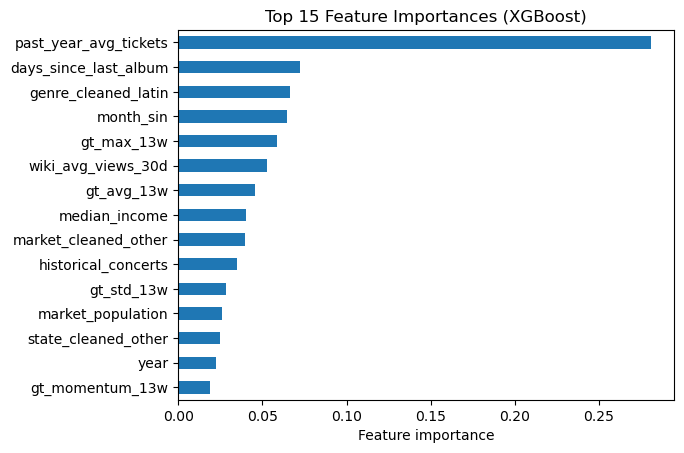

KeyError: 'demand_tier'

In [28]:
from xgboost import plot_importance

# feature names + importance scores
imp = pd.Series(model.feature_importances_, index=X_train.columns)

top15 = imp.sort_values(ascending=False).head(15)

plt.figure()
top15.sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

# Model 2: LightGBM

In [ ]:
import lightgbm as lgb
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=3,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42
)

model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(y_true, y_pred, name):
    print(name)
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate(y_train, y_train_pred, "Train")
evaluate(y_test, y_test_pred, "Test")

# feature names + importance scores
# Get gain importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.booster_.feature_importance(importance_type='gain')
})

# Normalize
importance['importance'] = importance['importance'] / importance['importance'].sum()

# Sort
importance = importance.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    importance['feature'][:15][::-1],
    importance['importance'][:15][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (LightGBM)")
plt.xlim(0, importance['importance'][:15].max() * 1.1)  # similar scaling

plt.show()

## Model 3: Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000,
    random_state=42
)

lasso_model.fit(X_train, y_train)

y_train_pred = lasso_model.predict(X_train)
y_test_pred = lasso_model.predict(X_test)

def evaluate(y_true, y_pred, name):
    print(name)
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate(y_train, y_train_pred, "Train")
evaluate(y_test, y_test_pred, "Test")

# feature importance:
importance = np.abs(lasso_model.coef_)

lasso_importance = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': importance
    })
    .sort_values(by='importance', ascending=False)
)

print(lasso_importance.head(15))
import matplotlib.pyplot as plt

top = lasso_importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 15 Features (Lasso)")
plt.xlabel("Coefficient Magnitude")
plt.show()

## Model 4: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print("Train:")
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2:", r2_score(y_train, y_pred_train))

print("\nTest:")
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2:", r2_score(y_test, y_pred_test))

# Get feature importances
importances = rf_model.feature_importances_

# Normalize (so sum = 1, like XGBoost)
importances = importances / importances.sum()

feature_names = X_train.columns  # if DataFrame

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 15
top_features = feat_df.head(15)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Feature importance")

plt.show()

## Model 5: Catboost

In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=100
)

cat_model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_train = cat_model.predict(X_train)
y_pred_test = cat_model.predict(X_test)

print("Train:")
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2:", r2_score(y_train, y_pred_train))

print("\nTest:")
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2:", r2_score(y_test, y_pred_test))

import pandas as pd
import matplotlib.pyplot as plt

# Get importance
importances = cat_model.get_feature_importance()

# Normalize
importances = importances / importances.sum()

feature_names = X_train.columns

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top_features = feat_df.head(15)

# Plot
plt.figure(figsize=(8,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (CatBoost)")
plt.xlabel("Feature importance")

plt.show()